<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 5: Imputación de datos</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_5_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:#2F749F;"><strong>Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
        'Edad': [25, np.nan, 35, 29, -5, 25, None],
        'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
        'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
        'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
    })

2. En un nuevo notebook, aplica las etapas del proceso de limpieza e imputación de datos que consideres necesarias sobre el DataFrame df. Ten encuenta incluir:
    - Código correctamente comentado y ejecutado.
    - Explicaciones breves de cada paso.
    - Resultados visuales o estadísticos que evidencien las transformaciones.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
})

df

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,NaN,Medellín,4800.0,2023-01-05
2,Pedro,35.0,None,NaN,None
3,None,29.0,Medellín,5200.0,2023-01-10
4,Marta,-5.0,Cali,5100.0,2023-01-12
5,Luis,25.0,Bogotá,NaN,None
6,Sofía,NaN,Cali,4700.0,2023-01-15


In [ ]:
# Imputar NaN en Ingresos
df["Ingreso"] = df["Ingreso"].fillna(df["Ingreso"].median())

# Imputar nombre none con "Desconocido"
df["Nombre"] = df["Nombre"].fillna("Desconocido")

# Quitar los valores de edad negativo
df["Edad"] = df["Edad"].where(df["Edad"] >= 0, np.nan)

# Imputar la edad con la mediana
df["Edad"] = df["Edad"].fillna(df["Edad"].median())

# Eliminar Nan/None
df = df.dropna()

# Transformar las fechas
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')

df

/tmp/ipykernel_10498/3306431163.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')


,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,27.0,Medellín,4800.0,2023-01-05
3,Desconocido,29.0,Medellín,5200.0,2023-01-10
4,Marta,27.0,Cali,5100.0,2023-01-12
6,Sofía,27.0,Cali,4700.0,2023-01-15


## <span style="color:#2F749F;"><strong>Ejercicio 2. Limpieza de duplicados</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'ID': [101, 102, 102, 103, 104, 104, 104],
        'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
        'Edad': [25, 30, 30, 29, 40, 40, 41],
        'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
        'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                        '2023-01-15', '2023-01-15', '2023-01-16']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, responde a las siguientes preguntas (utilizando python):
    - ¿Cuál es el total de registros originales?
    - ¿Cuáles y cuántos son los duplicados exactos?
    - ¿Cuáles y cuántos son los duplicados por varias columnas?
    - ¿Cuántos registros debes eliminar?
    - ¿Cuántos registros quedan después de la limpieza?

In [ ]:
df = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})

df

,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


In [ ]:
# Total de registros originales
X, Y = df.shape
print(f'El total de registros originales es: {X}')

El total de registros originales es: 7


In [ ]:
# Mostrar registros duplicados
sum_duplicados = df.duplicated().sum()
print(f'Los registros duplicados son: {sum_duplicados}')
print('Se eliminan los siguientes registros: ')
df[df.duplicated(keep=False)]

Los registros duplicados son: 2
Se eliminan los siguientes registros: 


,ID,Nombre,Edad,Ciudad,FechaRegistro
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15


In [ ]:
df = df.drop_duplicates()
print('Después de limpiar quedan los siguientes registros: ')
df

Después de limpiar quedan los siguientes registros: 


,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


## <span style="color:#2F749F;"><strong>Ejercicio 3. Corrección de errores tipográficos o de codificación</strong></span>


1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, estandariza la variable ciudad utilizando python.

In [ ]:
df = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})

In [ ]:
# Estandarizar: Quitar espacios y poner en minúscula
df['Ciudad'] = df['Ciudad'].str.strip().str.lower()
df

,Ciudad
0,bogota
1,bogotá
2,bogota
3,bogotá
4,bogata
5,bógota
6,bogota
7,cali
8,calí
9,medellín


In [ ]:
# Eliminar tildes
df['Ciudad'] = df['Ciudad'].astype(str).str.normalize('NFD').str.encode('ascii', errors='ignore').str.decode('utf-8')
df

,Ciudad
0,bogota
1,bogota
2,bogota
3,bogota
4,bogata
5,bogota
6,bogota
7,cali
8,cali
9,medellin


## <span style="color:#2F749F;"><strong>Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)</strong></span>
1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.
2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
   - **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).
   - **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 3.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 4.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.
   - **Escenario 5.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.
   

**Escenario 1:** MCAR. No depende de otras variables observadas.

**Escenario 2:** MAR. Esto se debe a que los faltantes en Horas estudiadas depende de la variable observada promedio cuando sus valores son bajos.

**Escenario 3 :** Lo mismo de arriba :)

**Escenario 4:** MNAR. Los valores faltantes ocurren con mayor frecuencia en estudiantes de un género en particular, cómo si evitaran reportar su valor.

**Escenario 5:** MNAR. Los valores faltantes ocurren por decisición de algunos estudiantes de no reportar los valores.

## <span style="color:#2F749F;"><strong>Ejercicio 5. Imputación con KNN y regresión</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Edad': np.random.randint(18, 60, n),
            'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
            'Horas_estudio': np.random.randint(0, 40, n),
            'Ingreso_familiar': np.random.randint(800000, 8000000, n),
            'Semestres_cursados': np.random.randint(1, 10, n)
        })

        # Introducción de valores faltantes con distintos patrones
        df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
        df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
        df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

2. Al analizar el dataframe `df`:
   - ¿Qué variables tienen mayor proporción de datos faltantes?
   - ¿Observas algún patrón estructurado o parecen aleatorios?

3. Realiza la imputación de valores faltantes utilizando KNN y regresión
4. Analiza si se preserva la naturaleza de los datos con cada una de las técnicas de imputación (KNN y regresión)

In [8]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

In [3]:
df

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35.0,2909818.0,7
1,46,2.27,NaN,3031785.0,7
2,32,NaN,30.0,5283302.0,9
3,25,3.15,14.0,NaN,3
4,38,4.95,7.0,3525928.0,7
5,56,NaN,13.0,4653339.0,1
6,36,4.58,22.0,NaN,4
7,40,4.04,NaN,1879111.0,4
8,28,NaN,20.0,1796107.0,5
9,28,2.04,15.0,4321441.0,7


In [5]:
df.isnull().sum()

,0
Edad,0
Promedio,4
Horas_estudio,4
Ingreso_familiar,3
Semestres_cursados,0


Las variables con mayores valores faltantes son Promedio y Horas_estudio con 4 valores faltantes cada uno, lo que corresponde al 13.33%

In [9]:
display(df.sort_values(by='Edad'))

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
20,19,3.17,23.0,3791650.0,7
16,19,4.05,0.0,7045035.0,9
14,20,2.69,28.0,NaN,6
3,25,3.15,14.0,NaN,3
8,28,NaN,20.0,1796107.0,5
9,28,2.04,15.0,4321441.0,7
23,29,3.28,23.0,2748260.0,1
2,32,NaN,30.0,5283302.0,9
29,33,3.19,32.0,3936729.0,3
6,36,4.58,22.0,NaN,4


In [13]:
display(df.sort_values(by='Ingreso_familiar'))

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
22,50,4.27,7.0,1291234.0,7
8,28,NaN,20.0,1796107.0,5
7,40,4.04,NaN,1879111.0,4
25,42,3.70,16.0,2321101.0,9
12,57,3.16,25.0,2670230.0,7
23,29,3.28,23.0,2748260.0,1
0,56,2.70,35.0,2909818.0,7
19,55,2.52,8.0,2921690.0,4
1,46,2.27,NaN,3031785.0,7
4,38,4.95,7.0,3525928.0,7


Se organizaron los datos por Edad, Ingreso_familiar y semestre y **no parece haber ningún patrón en los datos faltantes**, al contrario, parece que los datos que faltan son aleatorios.

### Imputación de valores faltantes con KNN

In [14]:
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

# Imputación con valores faltantes
imputer = KNNImputer(n_neighbors=3)
df_imputed_array = imputer.fit_transform(df)

df_imputed = pd.DataFrame(df_imputed_array, columns=df.columns)
df_imputed

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56.0,2.700000,35.000000,2.909818e+06,7.0
1,46.0,2.270000,21.333333,3.031785e+06,7.0
2,32.0,3.473333,30.000000,5.283302e+06,9.0
3,25.0,3.150000,14.000000,2.955269e+06,3.0
4,38.0,4.950000,7.000000,3.525928e+06,7.0
5,56.0,3.473333,13.000000,4.653339e+06,1.0
6,36.0,4.580000,22.000000,3.609593e+06,4.0
7,40.0,4.040000,21.333333,1.879111e+06,4.0
8,28.0,3.473333,20.000000,1.796107e+06,5.0
9,28.0,2.040000,15.000000,4.321441e+06,7.0


### Imputación con regresión

Elegimos la variable salida. En este caso decidimos imputar la variable Promedio, utilizando Horas_estudio

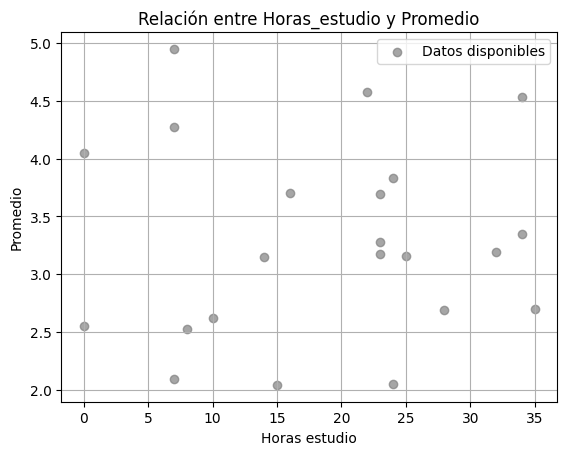

In [19]:
plt.scatter(df["Horas_estudio"], df["Promedio"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.xlabel("Horas estudio")
plt.ylabel("Promedio")
plt.title("Relación entre Horas_estudio y Promedio")
plt.legend()
plt.grid(True)
plt.show()

No se nota una correlación entre las variables, pero por motivos académicos se usarán igual :)

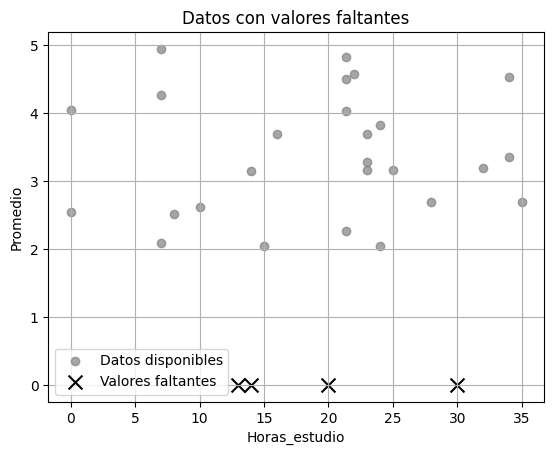

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


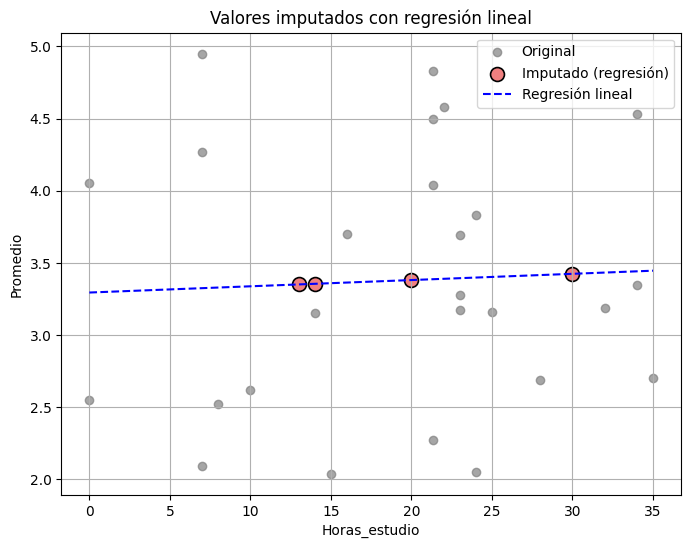

In [23]:
from sklearn.linear_model import LinearRegression

df["Horas_estudio"] = df_imputed["Horas_estudio"]

# Separar datos completos y faltantes
mask_missing = df["Promedio"].isnull()
X_train = df.loc[~mask_missing, ["Horas_estudio"]]
y_train = df.loc[~mask_missing, "Promedio"]

X_missing = df.loc[mask_missing, ["Horas_estudio"]]

# regresión lineal
reg = LinearRegression()
reg.fit(X_train, y_train)

# valores faltantes
data_imputed = df.copy()
data_imputed.loc[mask_missing, "Promedio"] = reg.predict(X_missing)

#plt.figure(figsize=(8,6))
plt.scatter(df["Horas_estudio"], df["Promedio"],
            color="gray", alpha=0.7, label="Datos disponibles")
plt.scatter(df.loc[mask_missing, "Horas_estudio"],
            [0]*mask_missing.sum(),
            marker="x", color="black", s=100, label="Valores faltantes")

plt.xlabel("Horas_estudio")
plt.ylabel("Promedio")
plt.title("Datos con valores faltantes")
plt.legend()
plt.grid(True)
plt.show()

#
plt.figure(figsize=(8,6))
plt.scatter(data_imputed.loc[~mask_missing, "Horas_estudio"],
            data_imputed.loc[~mask_missing, "Promedio"],
            color="gray", alpha=0.7, label="Original")
plt.scatter(data_imputed.loc[mask_missing, "Horas_estudio"],
            data_imputed.loc[mask_missing, "Promedio"],
            color="lightcoral", edgecolors="black", linewidths=1.2,
            s=100, label="Imputado (regresión)")
x_line = np.linspace(df["Horas_estudio"].min(), df["Horas_estudio"].max(), 100).reshape(-1,1)
y_line = reg.predict(x_line)
plt.plot(x_line, y_line, color="blue", linestyle="--", label="Regresión lineal")

plt.xlabel("Horas_estudio")
plt.ylabel("Promedio")
plt.title("Valores imputados con regresión lineal")
plt.legend()
plt.grid(True)
plt.show()

## <span style="color:#2F749F;"><strong>Ejercicio 6. Imputación con LOCF y NOCB</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
            'Ventas': np.round(np.random.uniform(100, 500, n), 2),
            'Inventario': np.random.randint(10, 100, n),
            'Clientes': np.random.randint(1, 50, n)
        })

        # Introducción de valores faltantes
        df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
        df.loc[[7, 8, 20], 'Inventario'] = np.nan
        df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
        df = df.sort_values('Fecha').reset_index(drop=True)

2. Al analizar el DataFrame `df`:
   - ¿Qué variables presentan datos faltantes consecutivos?
   - ¿Por qué este tipo de patrón es relevante en series temporales?
   - ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?
3. Realiza la imputación de valores faltantes utilizando LOCF y NOCB
4. ¿Cuál método consideras más apropiado para este caso y por qué?